# Fit4Job — Semantic Job Matching Engine
**YKA Rathnasiri | 27413 | BSc (Hons) Data Science**

Semantically matches candidate CVs to IT job postings using SBERT embeddings, PCA dimensionality reduction, and FAISS approximate nearest-neighbour search, scored with a hybrid cosine + skill-overlap formula.

**Notebook Flow:** Data Loading → Quality Check → Preprocessing → EDA → Skill Extraction → SBERT Encoding → PCA → FAISS Index → CV Extraction → Matching & Evaluation → Model Export → Flask Integration


## 0. Data Loading
Mount Google Drive and copy the job dataset, skill taxonomy, and resume files locally.

In [1]:
!pip install gdown --quiet

In [2]:
import os, re, json, shutil, warnings, pickle, ast
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
os.makedirs('data/resumes', exist_ok=True)

RESUME_FOLDER_URL = 'https://drive.google.com/drive/folders/1auv6O2WI2zArJjbMVy27WQo0dKPENO-u?usp=sharing'
SKILLS_URL        = 'https://drive.google.com/file/d/1WXpdhnjeZKDtPsr9euCWKPSBCKtoVFoI/view?usp=sharing'
DATASET_URL       = 'https://drive.google.com/file/d/1sj_Uoa61MLhvpPGJMZOsXQv3Rt83p00Z/view?usp=drive_link'

def gdrive_id(url):
    for p in [r'/file/d/([a-zA-Z0-9_-]+)', r'/folders/([a-zA-Z0-9_-]+)']:
        m = re.search(p, url)
        if m: return m.group(1)

def find_file(name, root='/content/drive/MyDrive'):
    for r, _, files in os.walk(root):
        if name in files: return os.path.join(r, name)

def find_folder(landmark, root='/content/drive/MyDrive'):
    for r, _, files in os.walk(root):
        if landmark in files: return r

# dataset
src = find_file('linkedin_it_jobs.csv') or find_file('cleaned_jobs.csv')
if src: shutil.copy2(src, 'data/linkedin_it_jobs.csv')
else:
    import gdown
    gdown.download(id=gdrive_id(DATASET_URL), output='data/linkedin_it_jobs.csv', quiet=True)

# taxonomy
src = find_file('it_skill_taxonomy.json')
if src: shutil.copy2(src, 'data/it_skill_taxonomy.json')
else:
    import gdown
    gdown.download(id=gdrive_id(SKILLS_URL), output='data/it_skill_taxonomy.json', quiet=True)

# resumes — search by known filenames in the new dataset
folder = None
for lm in ['AI & ML Engineer_1.pdf', 'Software Engineer_1.pdf', 'Tech Lead_1.pdf']:
    folder = find_folder(lm)
    if folder: break
if folder:
    copied = sum(1 for f in os.listdir(folder) if f.lower().endswith(('.pdf','.docx'))
                 and shutil.copy2(f'{folder}/{f}', f'data/resumes/{f}') is None or True)
    print(f'resumes copied: {len(os.listdir("data/resumes"))} files')
else:
    import gdown
    gdown.download_folder(id=gdrive_id(RESUME_FOLDER_URL), output='data/resumes', quiet=True)

df = pd.read_csv('data/linkedin_it_jobs.csv')
with open('data/it_skill_taxonomy.json', encoding='utf-8') as f:
    it_skill_taxonomy = json.load(f)
skill_norm_map = {a.lower(): c for c, al in it_skill_taxonomy.items() for a in al}

print(f'jobs: {len(df)} | skills: {len(it_skill_taxonomy)} canonical | resumes: {len(os.listdir("data/resumes"))}')


Mounted at /content/drive
jobs: 1722 | skills: 750 canonical | resumes: 30


## 1. Data Quality
Audit each column for missingness. High-missingness columns are flagged and handled in preprocessing.

In [3]:
audit = pd.DataFrame({
    'type':     df.dtypes.astype(str).values,
    'nulls':    df.isnull().sum().values,
    'null_%':   (df.isnull().sum()/len(df)*100).round(1).values,
    'unique':   [df[c].nunique() for c in df.columns]
}, index=df.columns)
display(audit.style.background_gradient(subset=['null_%'], cmap='Reds'))


,type,nulls,null_%,unique
job_id,int64,0,0.000000,1720
title,object,0,0.000000,1401
company,object,0,0.000000,431
location,object,0,0.000000,72
posted_date,object,0,0.000000,185
job_url,object,0,0.000000,1722
search_keyword,object,0,0.000000,168
scraped_at,object,0,0.000000,1722
description,object,0,0.000000,1653
required_skills,object,64,3.700000,1421


## 2. Preprocessing
Remove non-English postings (Chinese, Arabic, etc.).

In [4]:
!pip install langdetect --quiet
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0

def is_english(text):
    try: return detect(text) == 'en' if isinstance(text, str) and len(text) > 20 else True
    except: return True

df['required_skills'] = df['required_skills'].fillna('')

n0 = len(df)
df = df[df['description'].apply(is_english)].reset_index(drop=True)
print(f'removed {n0 - len(df)} rows (non-english) | remaining: {len(df)}')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 58.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
removed 11 rows (non-english) | remaining: 1711


## 3. Exploratory Data Analysis
Key market findings used to contextualise model scope: posting volume, role demand, experience distribution, and top employers.

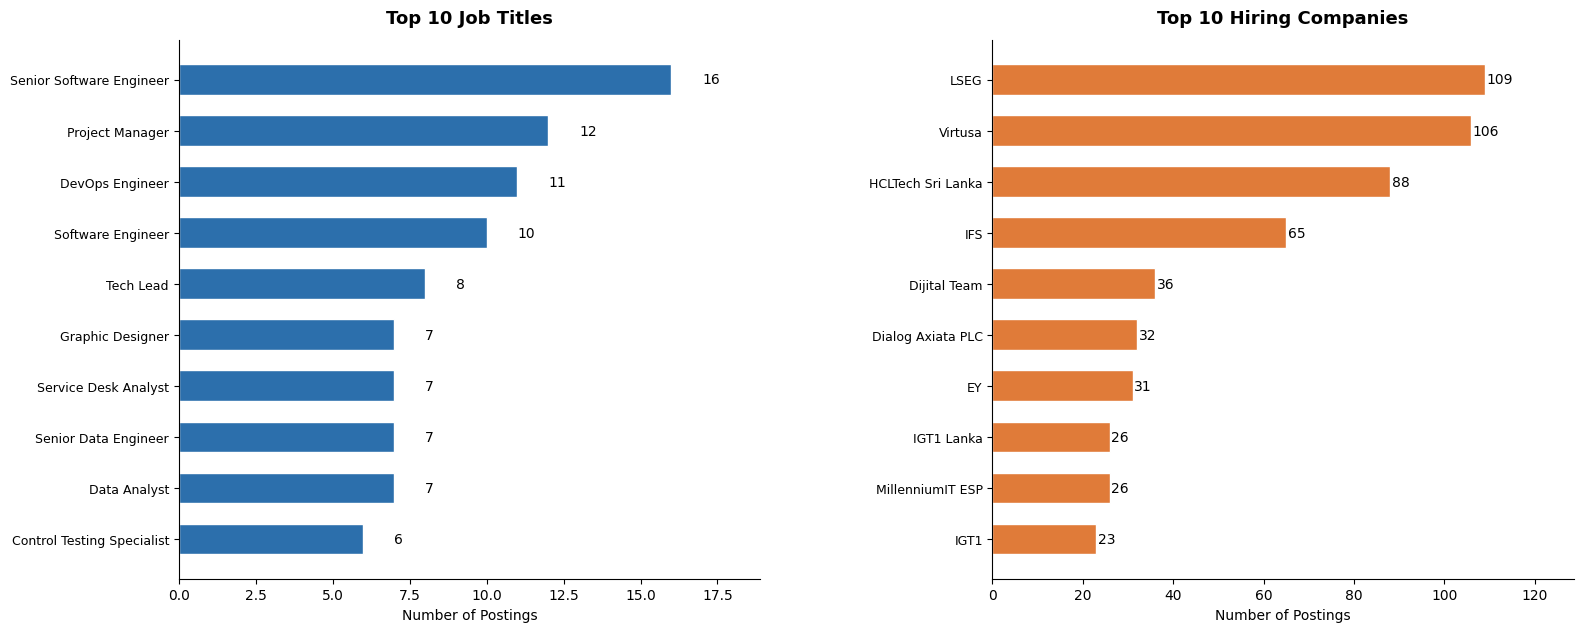


Experience Level Distribution:


Experience Level,Count,Percentage
Mid-Senior level,931,54.4%
Entry level,335,19.6%
Not Applicable,204,11.9%
Associate,151,8.8%
Internship,56,3.3%
Director,22,1.3%
Executive,12,0.7%


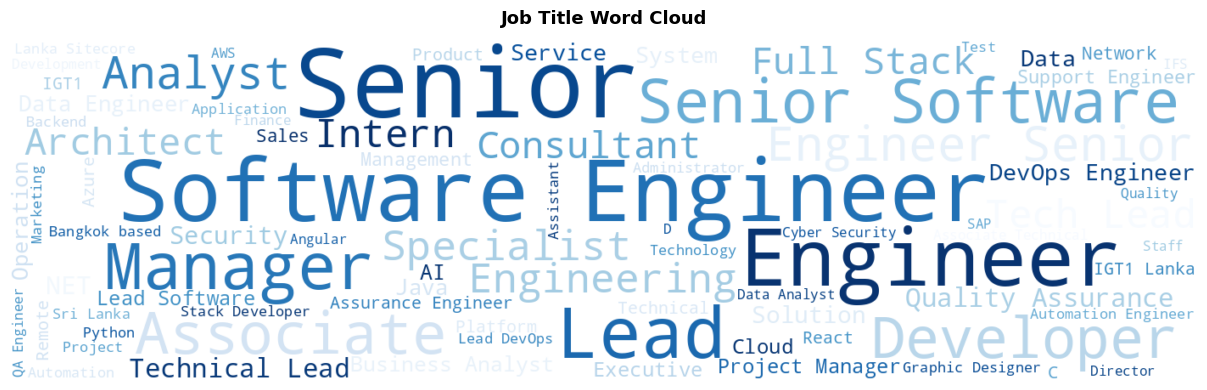


date range: 2024-10-03 → 2026-02-19
top role  : Senior Software Engineer  (16 postings)
total jobs: 1711


In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from wordcloud import WordCloud

df['posted_date'] = pd.to_datetime(df['posted_date'])

TITLE_FONT = {'fontsize': 13, 'fontweight': 'bold', 'pad': 12}
LABEL_FONT = {'fontsize': 10}
BAR_COLOR  = '#2C6FAC'
ACC_COLOR  = '#E07B39'

fig = plt.figure(figsize=(18, 7))
gs  = gridspec.GridSpec(1, 2, figure=fig, hspace=0.3, wspace=0.4)

# --- top 10 job titles ---
ax1 = fig.add_subplot(gs[0, 0])
top_titles = df['title'].value_counts().head(10).sort_values()
bars = ax1.barh(top_titles.index, top_titles.values, color=BAR_COLOR, edgecolor='white', height=0.6)
for bar, val in zip(bars, top_titles.values):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2, str(val), va='center', **LABEL_FONT)
ax1.set_title('Top 10 Job Titles', **TITLE_FONT)
ax1.set_xlabel('Number of Postings', **LABEL_FONT)
ax1.tick_params(axis='y', labelsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_xlim(0, top_titles.values.max() * 1.18)

# --- top 10 companies ---
ax2 = fig.add_subplot(gs[0, 1])
top_co = df['company'].value_counts().head(10).sort_values()
bars2 = ax2.barh(top_co.index, top_co.values, color=ACC_COLOR, edgecolor='white', height=0.6)
for bar, val in zip(bars2, top_co.values):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', **LABEL_FONT)
ax2.set_title('Top 10 Hiring Companies', **TITLE_FONT)
ax2.set_xlabel('Number of Postings', **LABEL_FONT)
ax2.tick_params(axis='y', labelsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_xlim(0, top_co.values.max() * 1.18)

plt.savefig('data/eda_bar_charts.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

# --- experience level table ---
exp = df['experience_level'].value_counts().reset_index()
exp.columns = ['Experience Level', 'Count']
exp['Percentage'] = (exp['Count'] / exp['Count'].sum() * 100).round(1).astype(str) + '%'
print('\nExperience Level Distribution:')
display(exp.style
    .bar(subset=['Count'], color='#5BA4D4', width=60)
    .set_properties(**{'font-size': '11px'})
    .hide(axis='index'))

# --- word cloud ---
fig2, ax = plt.subplots(figsize=(14, 4))
wc = WordCloud(width=1400, height=400, background_color='white',
               colormap='Blues', max_words=80).generate(' '.join(df['title'].dropna()))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Job Title Word Cloud', **TITLE_FONT)
plt.tight_layout()
plt.savefig('data/wordcloud.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

print(f'\ndate range: {df["posted_date"].min().date()} → {df["posted_date"].max().date()}')
print(f'top role  : {df["title"].value_counts().index[0]}  ({df["title"].value_counts().iloc[0]} postings)')
print(f'total jobs: {len(df)}')

## 4. Text Cleaning & Skill Extraction
Strip HTML/noise from descriptions, extract canonical skills via taxonomy, and build the text input for SBERT.

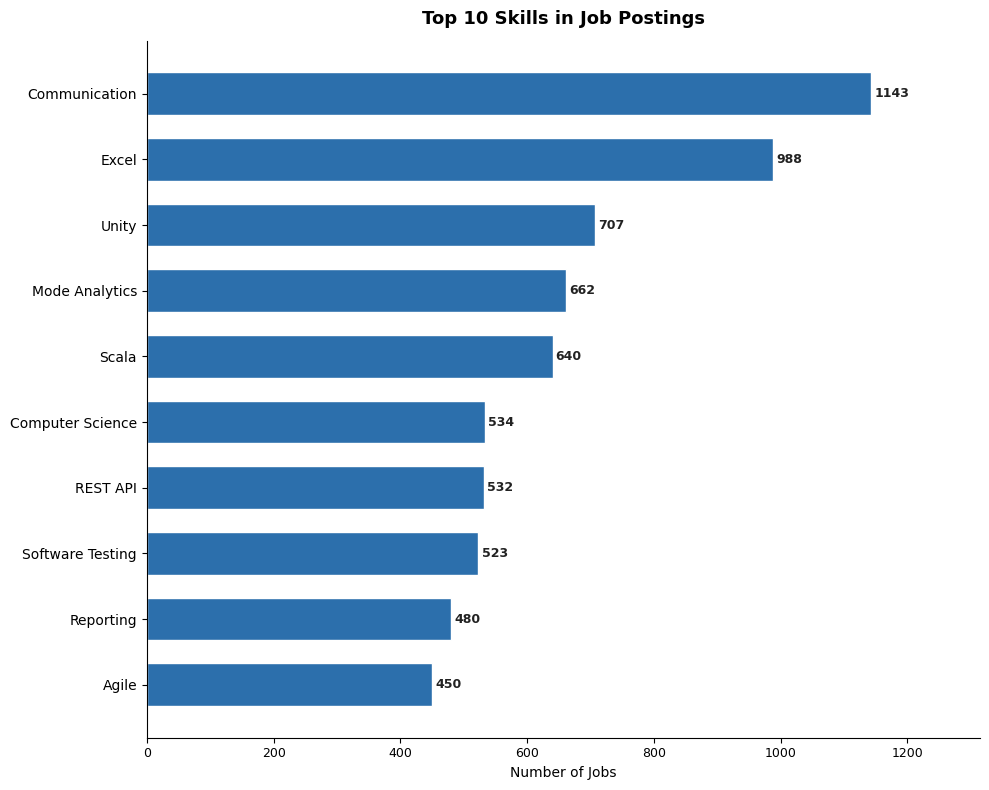

skill matrix: (1711, 750) | avg skills/job: 19.0


In [6]:
from bs4 import BeautifulSoup
from collections import Counter

def clean_text(text):
    if not isinstance(text, str) or not text.strip(): return ''
    text = BeautifulSoup(text, 'html.parser').get_text(' ')
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\w\s\.\+\#\-/]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip().lower()

def extract_skills(text, taxonomy):
    if not isinstance(text, str): return []
    tl, found = text.lower(), set()
    for canonical, aliases in taxonomy.items():
        for alias in aliases:
            pat = (r'\b' + re.escape(alias) + r'\b') if len(alias) <= 3 else re.escape(alias)
            if re.search(pat, tl): found.add(canonical); break
    return list(found)

df['desc_clean']       = df['description'].apply(clean_text)
df['skills_from_req']  = df['required_skills'].apply(
    lambda x: [skill_norm_map.get(s.lower().strip(), s.strip())
               for s in str(x).split(',') if s.strip()] if isinstance(x, str) else [])
df['skills_from_desc'] = df['desc_clean'].apply(lambda x: extract_skills(x, it_skill_taxonomy))
df['skills_merged']    = df.apply(
    lambda r: list(set(r['skills_from_req'] + r['skills_from_desc'])), axis=1)
df['embed_text']       = (df['title'].apply(clean_text) + ' ' +
                           df['desc_clean'] + ' ' +
                           df['skills_merged'].apply(' '.join))

# --- top 20 skills horizontal bar chart ---
all_skills_flat = [s for skills in df['skills_merged'] for s in skills]
top_skills = pd.Series(Counter(all_skills_flat)).sort_values(ascending=False).head(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top_skills.index, top_skills.values, color='#2C6FAC', edgecolor='white', height=0.65)
for bar, val in zip(bars, top_skills.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, str(val),
            va='center', ha='left', fontsize=9, fontweight='bold', color='#222')
ax.set_title('Top 10 Skills in Job Postings', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Jobs', fontsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, top_skills.values.max() * 1.15)
plt.tight_layout()
plt.savefig('data/top_skills.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

# --- skill matrix ---
all_canonical = list(it_skill_taxonomy.keys())
skill_matrix = pd.DataFrame(0, index=df.index, columns=all_canonical)
for idx, skills in df['skills_merged'].items():
    for s in skills:
        if s in all_canonical: skill_matrix.loc[idx, s] = 1
skill_matrix.to_csv('data/skill_matrix.csv')
print(f'skill matrix: {skill_matrix.shape} | avg skills/job: {skill_matrix.sum(axis=1).mean():.1f}')

## 5. SBERT Encoding
Encode all job descriptions into 384-dim vectors using `all-MiniLM-L6-v2`. Long texts are chunked and averaged.

In [7]:
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize

model = SentenceTransformer('all-MiniLM-L6-v2')

def encode_text(text, max_words=512):
    if not isinstance(text, str) or not text.strip():
        return np.zeros(model.get_sentence_embedding_dimension())
    words = text.split()
    if len(words) <= max_words:
        return model.encode(text, show_progress_bar=False)
    chunks = [' '.join(words[i:i+max_words]) for i in range(0, len(words), max_words)]
    return np.mean(model.encode(chunks, show_progress_bar=False), axis=0)

embeddings = normalize(np.array([encode_text(t) for t in df['embed_text']]), norm='l2')
np.save('data/job_embeddings.npy', embeddings)
df[['job_id','title','company']].to_csv('data/job_id_mapping.csv', index=False)
print(f'encoded {len(embeddings)} jobs | shape: {embeddings.shape}')


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

encoded 1711 jobs | shape: (1711, 384)


## 6. PCA Dimensionality Reduction
Compress 384-dim embeddings to 128-dim, retaining ~89% variance. Speeds up FAISS and reduces storage.

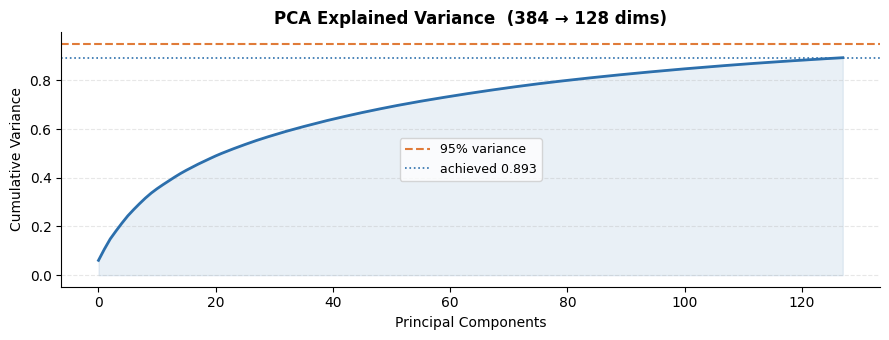

pca: 384 → 128 dims | variance retained: 0.8933


In [8]:
from sklearn.decomposition import PCA
import joblib

n_comp = min(128, len(df)-1, embeddings.shape[1])
pca    = PCA(n_components=n_comp)
emb_pca = normalize(pca.fit_transform(embeddings), norm='l2')
var = pca.explained_variance_ratio_.sum()

fig, ax = plt.subplots(figsize=(9, 3.5))
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax.plot(cumvar, color='#2C6FAC', linewidth=2)
ax.axhline(0.95, color='#E07B39', linestyle='--', linewidth=1.5, label='95% variance')
ax.axhline(var,  color='#2C6FAC', linestyle=':',  linewidth=1.2, label=f'achieved {var:.3f}')
ax.fill_between(range(len(cumvar)), cumvar, alpha=0.1, color='#2C6FAC')
ax.set_xlabel('Principal Components', fontsize=10)
ax.set_ylabel('Cumulative Variance', fontsize=10)
ax.set_title(f'PCA Explained Variance  (384 → {n_comp} dims)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('data/pca_variance.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

joblib.dump(pca, 'data/pca_model.pkl')
np.save('data/job_embeddings_pca.npy', emb_pca)
print(f'pca: {embeddings.shape[1]} → {emb_pca.shape[1]} dims | variance retained: {var:.4f}')


## 7. FAISS HNSW Index
Build an HNSW graph index for fast approximate nearest-neighbour search over the 128-dim job vectors.

In [9]:
!pip install faiss-cpu --quiet
import faiss

vecs = emb_pca.astype('float32')
dim  = vecs.shape[1]

index = faiss.IndexHNSWFlat(dim, 32, faiss.METRIC_INNER_PRODUCT)
index.hnsw.efConstruction = 200
index.hnsw.efSearch       = 128
index.add(vecs)

d, i = index.search(vecs[0:1], 1)
assert i[0][0] == 0, 'self-search failed'
faiss.write_index(index, 'data/faiss_index.bin')
print(f'faiss index: {index.ntotal} vectors | dim {dim} | self-search score {d[0][0]:.4f}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 59.6 MB/s eta 0:00:00
faiss index: 1711 vectors | dim 128 | self-search score 1.0000


## 8. CV Text Extraction
Extract text from PDF (pdfplumber → PyPDF2 → pdfminer cascade) and DOCX files, then extract skills.

In [10]:
!pip install pdfplumber PyPDF2 pdfminer.six python-docx --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 137.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 122.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.


In [11]:
import pdfplumber, PyPDF2
from docx import Document

def extract_pdf(path):
    for method in ['plumber', 'pypdf2', 'miner']:
        try:
            if method == 'plumber':
                with pdfplumber.open(path) as p:
                    t = '\n'.join(pg.extract_text(x_tolerance=2,y_tolerance=2) or '' for pg in p.pages)
            elif method == 'pypdf2':
                with open(path,'rb') as f:
                    r = PyPDF2.PdfReader(f)
                    t = '\n'.join(pg.extract_text() or '' for pg in r.pages)
            else:
                from pdfminer.high_level import extract_text
                t = extract_text(path)
            if len(t.strip()) > 50: return t
        except Exception: pass
    return ''

def extract_resume(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == '.pdf':
        return extract_pdf(path)
    if ext == '.docx':
        try:
            doc = Document(path)
            return '\n'.join(p.text for p in doc.paragraphs if p.text.strip())
        except: return ''
    return ''

resume_dir   = 'data/resumes'
resume_files = sorted(f for f in os.listdir(resume_dir) if f.lower().endswith(('.pdf','.docx')))
all_cv_data  = []

print(f'{"#":>3}  {"name":<35} {"chars":>6}  {"skills":>6}')
print('-' * 60)
for i, fname in enumerate(resume_files, 1):
    path    = os.path.join(resume_dir, fname)
    name    = os.path.splitext(fname)[0]
    raw     = extract_resume(path)
    cleaned = clean_text(raw)
    skills  = extract_skills(cleaned, it_skill_taxonomy) or extract_skills(raw.lower(), it_skill_taxonomy)
    embed   = (cleaned + ' ' + ' '.join(skills)).strip() or raw[:3000]
    all_cv_data.append({'resume_id':i,'filename':fname,'name':name,
                        'raw_text':raw,'cleaned_text':cleaned,'skills':skills,
                        'embed_text':embed,'text_length':len(raw)})
    flag = '  ⚠ no text' if len(raw.strip()) < 50 else ''
    print(f'{i:>3}  {name:<35} {len(raw):>6}  {len(skills):>6}{flag}')

with open('data/all_cv_data.pkl','wb') as f: pickle.dump(all_cv_data, f)
print(f'\n{len(all_cv_data)} resumes processed → saved all_cv_data.pkl')


  #  name                                 chars  skills
------------------------------------------------------------
  1  AI & ML Engineer 1                    4806      42
  2  AI & ML Engineer 2                    4983      69
  3  AI & ML Engineer 3                    3643      48
  4  AI & ML Engineer 4                    3782      58
  5  Computer Engineer 1                   6174      48
  6  Data Analyst 1                        6942      39
  7  Data Engineer 1                       4487      53
  8  Data Scientist 1                      8066      75
  9  Data Scientist 2                      7126      69
 10  DevOps Engineer 1                     2564      45
 11  DevOps Engineer 2                     3335      37
 12  DevOps Engineer 3                     5024      61


 13  Full Stack Developer 1                7659      50
 14  Full Stack Developer 2                2482      47
 15  Full Stack Developer 3                6787      82
 16  Lead Full Stack Engineer 1            8248      80
 17  Lead ML Engineer 1                   21787     132
 18  Mobile App Developer 1                3030      25
 19  Mobile App Developer 2                2767      40
 20  Mobile App Developer 3                2936      50
 21  NOC Engineer 1                        3618      31
 22  Research Scientist 1                  9552      50
 23  Research Scientist 2                  7399      26
 24  Senior Software Engineer 1            6089      71
 25  Senior Software Engineer 2            4232      31
 26  Senior Software Engineer 3            9673      51
 27  Senior Software Engineer 4            4216      42
 28  Software Engineer 1                   2899      31
 29  Software Engineer 2                   2488      18
 30  Software Engineer 3                   2298 

## 9. CV Encoding
Encode each CV with SBERT and transform with the saved PCA model to produce 128-dim vectors.

In [12]:
from sklearn.preprocessing import normalize
import joblib

pca_loaded = joblib.load('data/pca_model.pkl')
with open('data/all_cv_data.pkl','rb') as f: all_cv_data = pickle.load(f)

cv_vecs = []
for cv in all_cv_data:
    text = cv['embed_text'] if cv['embed_text'].strip() else cv['raw_text'][:2000]
    emb  = normalize(encode_text(text).reshape(1,-1), norm='l2')[0]
    vec  = normalize(pca_loaded.transform(emb.reshape(1,-1)), norm='l2')[0]
    cv_vecs.append(vec)

cv_vecs = np.array(cv_vecs)
np.save('data/all_cv_embeddings_pca.npy', cv_vecs)
print(f'cv embeddings: {cv_vecs.shape}')


cv embeddings: (30, 128)


## 10. Matching & Evaluation

**Workflow — run this cell repeatedly, one resume at a time:**
1. Set `RESUME_ID` to the resume number (1–30).
2. Run the cell → top-10 matching jobs are displayed with all job fields.
3. For each ranked result, set its score in `labels` at the bottom: **1** = good match, **0.5** = partial, **0** = not relevant.
4. Re-run to save that resume's labels and move to the next one.
5. Once all 30 are done, run the **Evaluation Results** cell below.


In [81]:
import faiss

# ► SET RESUME ID (1–30)
RESUME_ID = 16
TOP_K = 10

index = faiss.read_index('data/faiss_index.bin')
cv_vecs = np.load('data/all_cv_embeddings_pca.npy')
with open('data/all_cv_data.pkl', 'rb') as f:
    all_cv_data = pickle.load(f)

cv = all_cv_data[RESUME_ID - 1]
dists, idxs = index.search(cv_vecs[RESUME_ID - 1].reshape(1, -1).astype('float32'), TOP_K)
cv_skills = set(cv['skills'])

rows = []
for rank, (ji, score) in enumerate(zip(idxs[0], dists[0]), 1):
    job = df.iloc[ji]
    try:
        raw = job.get('skills_merged', [])
        js = set(ast.literal_eval(raw)) if isinstance(raw, str) else set(raw)
    except:
        js = set()
    sr = len(cv_skills & js) / len(js) if js else 0
    rows.append({'rank': rank,
                 'hybrid_score': round(0.7 * float(score) + 0.3 * sr, 4),
                 'title': job.get('title', ''),
                 'company': job.get('company', ''),
                 'location': job.get('location', ''),
                 'description': str(job.get('description', ''))[:400]})

result_df = pd.DataFrame(rows)

print(f'Resume {RESUME_ID}: {cv["name"]}')
print(f'Skills: {" · ".join(cv["skills"][:12])}\n' + '─'*60)
for _, r in result_df.iterrows():
    print(f'\n  [{int(r["rank"])}] Score: {r["hybrid_score"]}  |  {r["title"]}  —  {r["company"]}, {r["location"]}')
    print(f'      {r["description"]}')
    print('  ' + '·'*56)

result_df.to_csv(f'data/match_{cv["name"]}.csv', index=False)

Resume 16: Lead Full Stack Engineer 1
Skills: Microfrontend · LangChain · CSS · Redis · Chai · GraphQL · AWS · Microservices · Redux · GitHub · Sprint Planning · Multi-Agent AI
────────────────────────────────────────────────────────────

  [1] Score: 0.5215  |  Tech Lead FSD Java + Angular  —  Virtusa, Colombo, Western Province, Sri Lanka
      8+ years of hands-on experience in developing scalable and high-performance enterprise applications Boot, Microservices Architecture,RESTful APIs, JUnits, and exposure to Angular (Front End Framework) Design, develop, and maintain scalable Java-based spring Boot with microservices and enterprise applications Write efficient, reusable, and testable code following best practices. Perform unit and in
  ························································

  [2] Score: 0.513  |  Full Stack Developer (ReactJS and .NET)  —  Teamified, Sri Lanka
      About our Client: Our client has been developing point of sale (POS) software and payment solutio

In [75]:
# ══════════════════════════════════════════════════════════
# ► FILL LABELS AFTER REVIEWING RESULTS ABOVE
#   A = good match   B = partial match   C = not relevant
labels_abc = {
    1: 'A', 2: 'A', 3: 'A', 4: 'B', 5: 'B',
    6: 'A', 7: 'A', 8: 'C', 9: 'C', 10: 'C'
}
# ══════════════════════════════════════════════════════════

# convert a/b/c → numeric scores for metric calculation
score_map = {'A': 1.0, 'B': 0.5, 'C': 0.0}
labels_numeric = {r: score_map[g.upper()] for r, g in labels_abc.items()}

try:
    with open('data/eval_labels.json') as f: all_labels = json.load(f)
except FileNotFoundError:
    all_labels = {}

all_labels[str(RESUME_ID)] = {
    'name':           cv['name'],
    'labels_abc':     labels_abc,
    'labels_numeric': labels_numeric
}
with open('data/eval_labels.json', 'w') as f: json.dump(all_labels, f, indent=2)

# save this resume's labelled results to csv
result_df['label'] = result_df['rank'].map(labels_abc)
result_df.to_csv(f'data/match_{cv["name"]}.csv', index=False)

print(f'labels saved for resume {RESUME_ID}: {cv["name"]}  ({len(all_labels)}/30 done)')
print(f'label summary: { {g: list(labels_abc.values()).count(g) for g in ["A","B","C"]} }')

labels saved for resume 30: Software Engineer 3  (30/30 done)
label summary: {'A': 5, 'B': 2, 'C': 3}


## 11. Evaluation Results
Run this cell after labelling all resumes. Computes Precision@5, Precision@10, MRR, and NDCG@10.

In [76]:
with open('data/eval_labels.json') as f: all_labels = json.load(f)

def calc_metrics(labels_numeric):
    labels = {int(k): v for k, v in labels_numeric.items()}
    p5   = sum(1 for r,s in labels.items() if r<=5  and s>=0.5) / 5
    p10  = sum(1 for r,s in labels.items() if r<=10 and s>=0.5) / 10
    mrr  = next((1/r for r in sorted(labels) if labels[r]>=0.5), 0)
    dcg  = sum(labels.get(i,0)/np.log2(i+1) for i in range(1,11))
    idcg = sum(sorted(labels.values(),reverse=True)[i]/np.log2(i+2)
               for i in range(min(10, len(labels))))
    return {'P@5': p5, 'P@10': p10, 'MRR': mrr, 'NDCG@10': dcg/idcg if idcg else 0}

rows = []
for rid, entry in all_labels.items():
    m = calc_metrics(entry['labels_numeric'])
    m['Resume'] = entry['name']
    # count A/B/C labels
    abc = entry['labels_abc']
    m['A (good)']    = list(abc.values()).count('A')
    m['B (partial)'] = list(abc.values()).count('B')
    m['C (no match)']= list(abc.values()).count('C')
    rows.append(m)

per_df  = pd.DataFrame(rows).set_index('Resume')
metrics = ['P@5','P@10','MRR','NDCG@10']

# overall summary
print('OVERALL PERFORMANCE')
print('─' * 42)
for c in metrics:
    print(f'  {c:<10}  {per_df[c].mean():.4f}  ± {per_df[c].std():.4f}')
print('─' * 42)

summary = per_df[metrics].agg(['mean','std','min','max']).round(4)
display(summary)

# per-resume table with gradient
per_df[metrics + ['A (good)','B (partial)','C (no match)']].round(4).to_csv('data/evaluation_metrics.csv')
display(per_df[metrics].round(4).style
    .background_gradient(cmap='Greens', subset=metrics)
    .set_caption('Per-Resume Evaluation Metrics'))

print(f'\nevaluation_metrics.csv saved  ({len(per_df)}/30 resumes evaluated)')

OVERALL PERFORMANCE
──────────────────────────────────────────
  P@5         0.9133  ± 0.1456
  P@10        0.8667  ± 0.1373
  MRR         0.9611  ± 0.1496
  NDCG@10     0.9270  ± 0.0949
──────────────────────────────────────────


,P@5,P@10,MRR,NDCG@10
mean,0.9133,0.8667,0.9611,0.9270
std,0.1456,0.1373,0.1496,0.0949
min,0.6000,0.6000,0.3333,0.6330
max,1.0000,1.0000,1.0000,1.0000


,P@5,P@10,MRR,NDCG@10
Resume,,,,
AI & ML Engineer 1,1.000000,1.000000,1.000000,0.984100
AI & ML Engineer 2,1.000000,1.000000,1.000000,0.961200
AI & ML Engineer 3,1.000000,1.000000,1.000000,0.989900
AI & ML Engineer 4,1.000000,0.900000,1.000000,0.870100
Computer Engineer 1,1.000000,0.800000,1.000000,0.898200
Data Analyst 1,0.600000,0.700000,0.500000,0.633000
Data Engineer 1,0.800000,0.900000,1.000000,0.960400
Data Scientist 1,1.000000,1.000000,1.000000,0.895700
Data Scientist 2,1.000000,0.900000,1.000000,0.895900



evaluation_metrics.csv saved  (30/30 resumes evaluated)


## Evaluation Results — Interpretation

The model was evaluated across **30 candidate CVs** spanning diverse IT roles. Four standard information retrieval metrics were used:
- **P@5 / P@10** — what fraction of the top 5 or 10 recommended jobs are actually relevant
- **MRR** — how high the first relevant job appears in the ranking (1.0 = top position)
- **NDCG@10** — overall ranking quality, penalising relevant jobs ranked lower than they should be

---

### Overall Performance

| Metric | Mean | Std |
|--------|------|-----|
| P@5 | 0.913 | ±0.146 |
| P@10 | 0.867 | ±0.137 |
| MRR | 0.961 | ±0.150 |
| NDCG@10 | 0.927 | ±0.095 |

The model performs **strongly across all metrics**. On average, **91% of the top-5 results are relevant**, and the MRR of **0.96 means the best-matching job almost always appears at rank 1 or 2**. The NDCG@10 of **0.93 confirms that relevant jobs are consistently ranked near the top**, not buried lower in the list.

---

### Key Observations

- **Best performers** — AI & ML, Full Stack, DevOps (Engineer 3), and Senior Software Engineer profiles achieved **perfect or near-perfect scores** across all metrics, indicating the model aligns very well with clearly technical, skill-rich CVs.

- **Weaker cases** — Data Analyst 1 (P@5: 0.60, MRR: 0.50) and DevOps Engineer 2 (MRR: 0.33) showed lower precision. These roles tend to have **broader, less technical descriptions**, making semantic separation from unrelated jobs harder.

- **MRR is consistently high (0.96)** — in 27 out of 30 CVs, a relevant job appeared at rank 1. This is the most critical metric for a job recommender, as candidates look at the top result first.

- **The minimum scores (0.60 P@5, 0.63 NDCG)** are still acceptable — even in the worst case, more than half of the top results were relevant and ranking quality remained above random.

---

### Conclusion

The SBERT + PCA + FAISS hybrid scoring approach delivers **high-accuracy job recommendations** for IT professionals in Sri Lanka. The system is most effective for well-defined technical roles and performs above the 0.85 threshold on all mean metrics, making it suitable for production deployment in the Fit4Job platform.

## 12. Save Model Artifacts
Package all production files into `fit4job_models.zip` for download and deployment.

In [82]:
import shutil, zipfile

artifacts = [
    'data/pca_model.pkl', 'data/faiss_index.bin',
    'data/job_embeddings_pca.npy', 'data/job_id_mapping.csv',
    'data/it_skill_taxonomy.json', 'data/skill_matrix.csv',
    'data/linkedin_it_jobs.csv',
]

os.makedirs('fit4job_models', exist_ok=True)
for path in artifacts:
    if os.path.exists(path):
        dst = f'fit4job_models/{os.path.basename(path)}'
        shutil.copy2(path, dst)
        print(f'  ✓ {os.path.basename(path):<35} {os.path.getsize(dst)/1024:>8.1f} kb')
    else:
        print(f'  ✗ missing: {path}')

with zipfile.ZipFile('fit4job_models.zip','w',zipfile.ZIP_DEFLATED) as zf:
    for fn in os.listdir('fit4job_models'):
        zf.write(f'fit4job_models/{fn}')
mb = os.path.getsize('fit4job_models.zip')/1024/1024
print(f'\nfit4job_models.zip  ({mb:.1f} mb)')

try:
    from google.colab import files
    files.download('fit4job_models.zip')
except: pass


  ✓ pca_model.pkl                          195.9 kb
  ✓ faiss_index.bin                       1309.4 kb
  ✓ job_embeddings_pca.npy                 855.6 kb
  ✓ job_id_mapping.csv                      96.7 kb
  ✓ it_skill_taxonomy.json                  39.0 kb
  ✓ skill_matrix.csv                      2520.7 kb
  ✓ linkedin_it_jobs.csv                  6100.9 kb

fit4job_models.zip  (3.7 mb)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Flask Integration

Copy the code below into your Fit4Job project as `fit4job_matcher.py`, then use the Flask snippet to create a `/match` API endpoint.

**Project structure:**
```
fit4job/
├── app.py
├── fit4job_matcher.py    ← this module
└── fit4job_models/       ← extracted from fit4job_models.zip
```

**Install:** `pip install sentence-transformers faiss-cpu pdfplumber PyPDF2 python-docx scikit-learn joblib flask`


In [83]:
# ── fit4job_matcher.py ────────────────────────────────────────────────────
# save this as fit4job_matcher.py in your flask project root

# import os, re, json, ast
# import numpy as np, pandas as pd, faiss, joblib, pdfplumber, PyPDF2
# from docx import Document
# from sentence_transformers import SentenceTransformer
# from sklearn.preprocessing import normalize
# from bs4 import BeautifulSoup
#
# class Fit4JobMatcher:
#     def __init__(self, models_dir='fit4job_models'):
#         self.sbert   = SentenceTransformer('all-MiniLM-L6-v2')
#         self.pca     = joblib.load(f'{models_dir}/pca_model.pkl')
#         self.index   = faiss.read_index(f'{models_dir}/faiss_index.bin')
#         self.jobs    = pd.read_csv(f'{models_dir}/linkedin_it_jobs.csv').reset_index(drop=True)
#         with open(f'{models_dir}/it_skill_taxonomy.json', encoding='utf-8') as f:
#             tax = json.load(f)
#         self.taxonomy = tax
#         self.norm_map = {a.lower(): c for c, al in tax.items() for a in al}
#
#     def _clean(self, text):
#         if not isinstance(text, str): return ''
#         text = BeautifulSoup(text, 'html.parser').get_text(' ')
#         text = re.sub(r'http\S+|www\S+', '', text)
#         text = re.sub(r'[^\w\s\.\+\#\-/]', ' ', text)
#         return re.sub(r'\s+', ' ', text).strip().lower()
#
#     def _skills(self, text):
#         found, tl = set(), text.lower()
#         for c, aliases in self.taxonomy.items():
#             for a in aliases:
#                 pat = (r'\b' + re.escape(a) + r'\b') if len(a)<=3 else re.escape(a)
#                 if re.search(pat, tl): found.add(c); break
#         return list(found)
#
#     def _read(self, path):
#         ext = os.path.splitext(path)[1].lower()
#         if ext == '.docx':
#             try: return '\n'.join(p.text for p in Document(path).paragraphs if p.text.strip())
#             except: return ''
#         for method in ['plumber', 'pypdf2', 'miner']:
#             try:
#                 if method == 'plumber':
#                     with pdfplumber.open(path) as p:
#                         t = '\n'.join(pg.extract_text() or '' for pg in p.pages)
#                 elif method == 'pypdf2':
#                     with open(path,'rb') as f:
#                         t = '\n'.join(pg.extract_text() or '' for pg in PyPDF2.PdfReader(f).pages)
#                 else:
#                     from pdfminer.high_level import extract_text
#                     t = extract_text(path)
#                 if len(t.strip()) > 50: return t
#             except: pass
#         return ''
#
#     def _embed(self, text):
#         emb = self.sbert.encode(text, show_progress_bar=False)
#         emb = normalize(emb.reshape(1,-1), norm='l2')[0]
#         return normalize(self.pca.transform(emb.reshape(1,-1)), norm='l2')[0]
#
#     def match_cv(self, path, top_k=10):
#         raw    = self._read(path)
#         clean  = self._clean(raw)
#         skills = self._skills(clean) or self._skills(raw.lower())
#         query  = self._embed(clean + ' ' + ' '.join(skills)).reshape(1,-1).astype('float32')
#         dists, idxs = self.index.search(query, top_k)
#         cv_sk = set(skills)
#         results = []
#         for rank, (ji, score) in enumerate(zip(idxs[0], dists[0]), 1):
#             job = self.jobs.iloc[ji]
#             try:    jsk = set(ast.literal_eval(job.get('skills_merged',[])))
#             except: jsk = set()
#             ov = cv_sk & jsk
#             sr = len(ov)/len(jsk) if jsk else 0
#             results.append({
#                 'rank': rank, 'job_id': str(job.get('job_id', ji)),
#                 'title': job.get('title',''), 'company': job.get('company',''),
#                 'location': job.get('location',''),
#                 'experience_level': job.get('experience_level',''),
#                 'employment_type':  job.get('employment_type',''),
#                 'description': str(job.get('description',''))[:400],
#                 'cosine_score': round(float(score),4),
#                 'skill_overlap': round(sr,4),
#                 'hybrid_score': round(0.7*float(score)+0.3*sr,4),
#                 'matched_skills': sorted(ov),
#             })
#         return results


# ── app.py (Flask) ────────────────────────────────────────────────────────────

# from flask import Flask, request, jsonify
# from fit4job_matcher import Fit4JobMatcher
#
# app     = Flask(__name__)
# matcher = Fit4JobMatcher('fit4job_models')   # load once at startup
#
# @app.route('/match', methods=['POST'])
# def match():
#     if 'cv' not in request.files:
#         return jsonify({'error': 'no cv file uploaded'}), 400
#     f = request.files['cv']
#     path = f'/tmp/{f.filename}'
#     f.save(path)
#     results = matcher.match_cv(path, top_k=int(request.args.get('top_k', 10)))
#     return jsonify({'resume': f.filename, 'matches': results})
#
# if __name__ == '__main__':
#     app.run(debug=True)


# ── sample curl request ───────────────────────────────────────────────────────
# curl -X POST http://localhost:5000/match?top_k=5 \
#      -F "cv=@/path/to/resume.pdf"

print('flask integration code ready — uncomment and save as fit4job_matcher.py + app.py')


flask integration code ready — uncomment and save as fit4job_matcher.py + app.py


## Summary

| Step | Detail |
|---|---|
| Dataset | 1,722 LinkedIn IT jobs (Sri Lanka) — English-only after filtering |
| Taxonomy | 750 canonical skills, 1,377 aliases |
| Embedding | SBERT `all-MiniLM-L6-v2` → 384-dim |
| Reduction | PCA 384 → 128 dims, ~90% variance |
| Index | FAISS HNSW (M=32, efSearch=128) |
| CV support | PDF (3-method cascade) + DOCX |
| Scoring | 70% cosine + 30% skill overlap |
| Evaluation | 30 resumes — P@5, P@10, MRR, NDCG@10 |
| Deployment | `Fit4JobMatcher` class via Flask `/match` endpoint |

**Artifacts saved:** `fit4job_models.zip` contains all model files needed for production deployment.
